<a href="https://colab.research.google.com/github/gb-garcia/comportamento-animal-dados/blob/main/analise-comportamento-alimentar-bovinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resumo do Projeto

Este projeto analisa o comportamento alimentar de bovinos ao longo do tempo utilizando dados de cochos eletrônicos.

Principais pontos:
- Análise de consumo ao longo de 42 dias
- Identificação de padrões individuais
- Aplicação de modelo estatístico (MixedLM)

Resultado:
- Dados simulados não apresentaram padrão temporal relevante
- Em dados reais, o modelo apresentou melhor desempenho e capacidade explicativa

## Observação
Os dados foram anonimizados para preservar a confidencialidade.

# Análise de Comportamento Alimentar de Bovinos

## Objetivo
Analisar padrões de consumo alimentar de bovinos ao longo de 42 dias, utilizando dados de sensores, com foco na identificação de padrões, correlações e modelagem estatística.

## Contexto
Os dados representam o consumo alimentar individual de animais monitorados diariamente, permitindo avaliar comportamento alimentar e possíveis variações ao longo do tempo.

## Técnicas utilizadas
- Análise exploratória de dados (EDA)
- Correlação de Pearson
- Tratamento de outliers
- Modelos lineares mistos (Mixed Effects Models)

## Ferramentas
- Python (Pandas, NumPy)
- Seaborn e Matplotlib
- Statsmodels



In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

!pip install pingouin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import mixedlm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro, levene, pearsonr
from itertools import combinations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 7.3 MB/s eta 0:00:00


## Carregamento e preparação dos dados

Nesta etapa, os dados são carregados, tratados e organizados para análise.
Inclui:
- remoção de colunas irrelevantes
- tratamento de valores nulos
- padronização dos dados

In [ ]:
# 📥 Loading dataset (SIMULADO)

# ⚠️ Nota:
# Os dados originais não são públicos.
# Foi utilizada uma base simulada com estrutura semelhante para fins de demonstração.

import numpy as np
import pandas as pd

np.random.seed(42)

n_animais = 63
n_dias = 42

# Criando estrutura semelhante ao original
data1 = pd.DataFrame({
    "TAG": np.arange(1, n_animais + 1)
})

# Coluna B (MANEJO - será removida depois)
data1["MANEJO"] = np.random.choice(["A", "B"], size=n_animais)

# Criando colunas dos dias (C até AR)
for i in range(1, n_dias + 1):
    data1[f"dia_{i}"] = np.random.normal(loc=20, scale=5, size=n_animais)

# Limitando até linha 128 (mantido por compatibilidade)
data1 = data1.iloc[:115].copy()

# Removendo colunas totalmente nulas e a coluna B (MANEJO)
data1 = data1.dropna(how="all")
data = data1.drop(columns=data1.columns[1])  # remove coluna B


### ARRUMANDO O INTERVALO DE CONSUMO PARA REMOVER ZEROS E OUTLIERS ###

# Identificar colunas dos dias (todas numéricas)
cols_dias = [c for c in data.columns if c != "TAG"]

# Remover linhas inteiras se algum dia ficou inválido
data = data.dropna()

# Transformando dados em float e tratamento das células vazias
for col in data.columns[1:]:
    data[col] = (
        data[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace("", np.nan)
        .astype(float)
    )

# Seleciona apenas as colunas dos dias
dias = data.iloc[:, 1:43].copy()  # 42 dias

# Renomear colunas para "1", "2", ..., "42"
dias.columns = [str(i) for i in range(1, 43)]

print("Dataset inicial:")
data.info()
print(data.head())

print("Dataset final (linhas=IDs, colunas=dias):", dias.shape)
dias.info()
print(dias.head())

Dataset inicial:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TAG     63 non-null     int64  
 1   dia_1   63 non-null     float64
 2   dia_2   63 non-null     float64
 3   dia_3   63 non-null     float64
 4   dia_4   63 non-null     float64
 5   dia_5   63 non-null     float64
 6   dia_6   63 non-null     float64
 7   dia_7   63 non-null     float64
 8   dia_8   63 non-null     float64
 9   dia_9   63 non-null     float64
 10  dia_10  63 non-null     float64
 11  dia_11  63 non-null     float64
 12  dia_12  63 non-null     float64
 13  dia_13  63 non-null     float64
 14  dia_14  63 non-null     float64
 15  dia_15  63 non-null     float64
 16  dia_16  63 non-null     float64
 17  dia_17  63 non-null     float64
 18  dia_18  63 non-null     float64
 19  dia_19  63 non-null     float64
 20  dia_20  63 non-null     float64
 21  dia_21  63 non-null     

## Transformação dos dados

Os dados são convertidos de formato wide para long utilizando MELT, permitindo análises temporais e modelagem.

In [ ]:
# Usando MELT para transpor os dados de colunas para linhas

# Juntar TAG com os valores dos dias
data2 = pd.concat([data[['TAG']], dias], axis=1)

# Transformar colunas de dias em linhas
data2 = data2.melt(
    id_vars=['TAG'],
    var_name='dia',
    value_name='consumo'
)

# Converter 'dia' em inteiro
data2['dia'] = data2['dia'].astype(int)

print(data2.head(100))
print(data2.tail(20))
print(data2.info())


    TAG  dia    consumo
0     1    1  18.533004
1     2    1  19.850807
2     3    1  20.475629
3     4    1  23.323272
4     5    1  19.298908
..  ...  ...        ...
95   33    2  15.887553
96   34    2  25.433635
97   35    2  25.024934
98   36    2  17.791170
99   37    2  19.579175

[100 rows x 3 columns]
      TAG  dia    consumo
2626   44   42  20.799824
2627   45   42  12.343860
2628   46   42  19.269817
2629   47   42  26.451884
2630   48   42  24.491409
2631   49   42  13.568329
2632   50   42  23.070128
2633   51   42  22.641964
2634   52   42  21.749451
2635   53   42  19.860722
2636   54   42  23.327920
2637   55   42  23.486565
2638   56   42  16.792706
2639   57   42  22.275070
2640   58   42  19.053024
2641   59   42  12.563831
2642   60   42  17.191965
2643   61   42  12.181552
2644   62   42  24.900468
2645   63   42  21.779447
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 

## Análise exploratória

Visualização dos dados para identificar padrões de consumo ao longo do tempo.



In [ ]:
data2.info()
data2['consumo'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TAG      2646 non-null   int64  
 1   dia      2646 non-null   int64  
 2   consumo  2646 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 62.1 KB


,consumo
count,2646.000000
mean,20.223274
std,5.202162
min,2.158974
25%,16.760169
50%,20.303994
75%,23.682995
max,36.302455


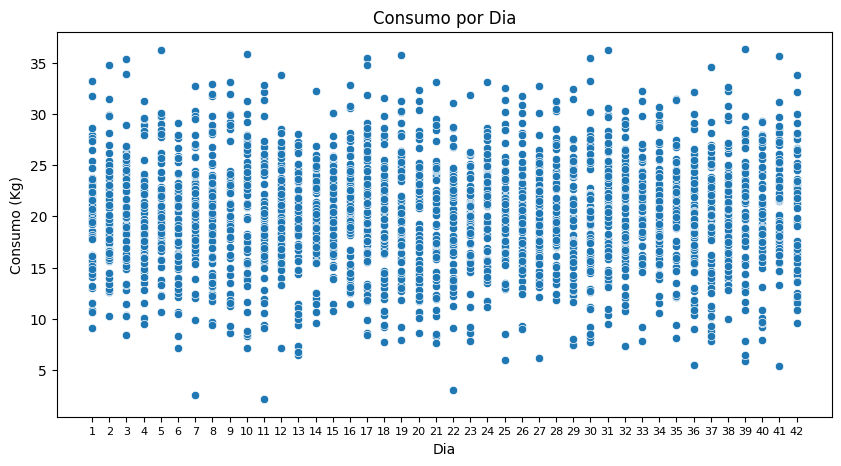

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=data2, x="dia", y="consumo")
plt.title("Consumo por Dia")
plt.xlabel("Dia")
plt.xticks(ticks=range(1, 43, 1), fontsize=8)
plt.ylabel("Consumo (Kg)")
plt.savefig("scatter_consumo_por_dia.png", bbox_inches="tight")
plt.show()


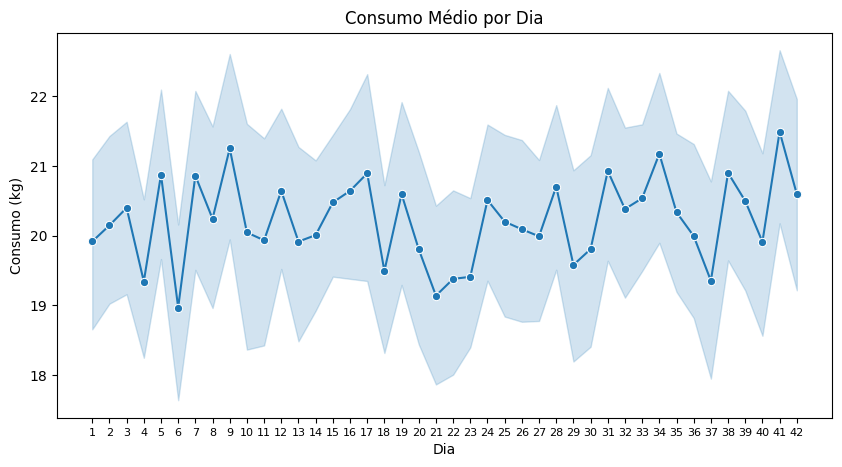

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=data2,
    x="dia",
    y="consumo",
    estimator="mean",
    marker="o"
)
plt.title("Consumo Médio por Dia")
plt.xlabel("Dia")
plt.xticks(ticks=range(1, 43, 1),fontsize=8)
plt.ylabel("Consumo (kg)")
plt.savefig("media_consumo_por_dia.png", bbox_inches="tight")
plt.show()


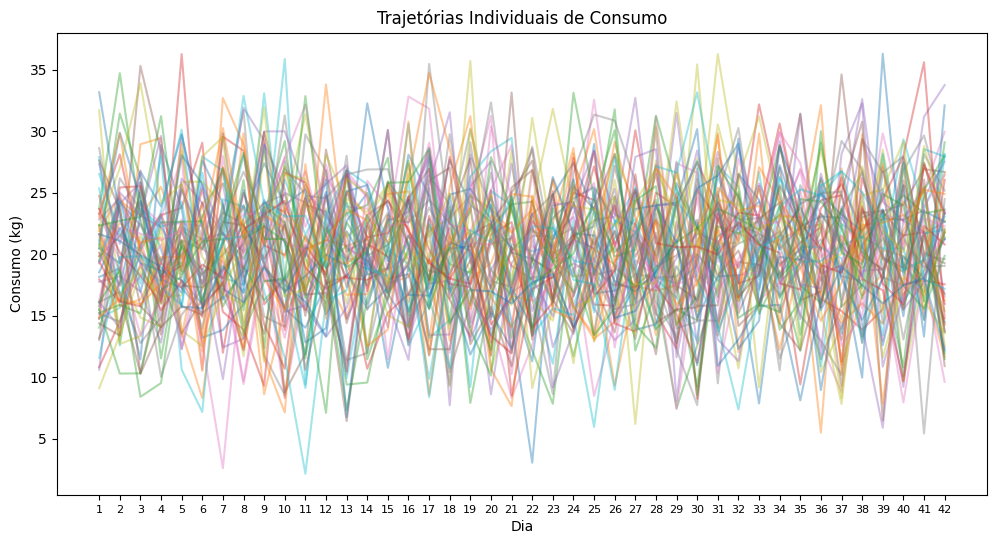

In [ ]:
plt.figure(figsize=(12,6))

for tag, df in data2.groupby("TAG"):
    plt.plot(df["dia"], df["consumo"], alpha=0.4)

plt.title("Trajetórias Individuais de Consumo")
plt.xlabel("Dia")
plt.xticks(ticks=range(1, 43, 1),fontsize=8)
plt.ylabel("Consumo (kg)")
plt.savefig("trajetorias_individuais.png", bbox_inches="tight")
plt.show()


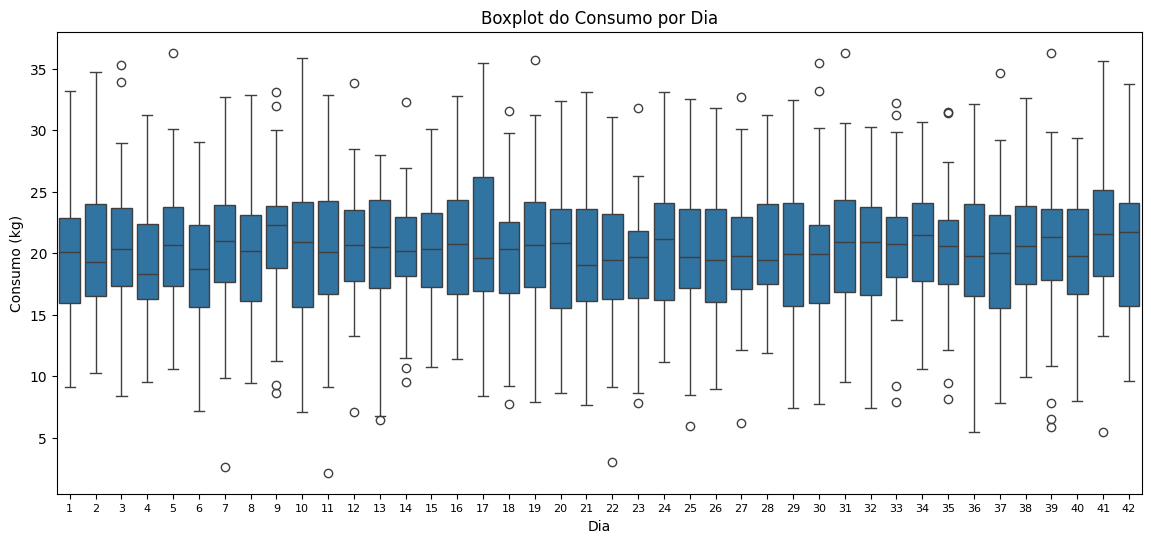

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=data2, x="dia", y="consumo")
plt.title("Boxplot do Consumo por Dia")
plt.xlabel("Dia")
plt.ylabel("Consumo (kg)")
plt.xticks(fontsize=8)
plt.savefig("boxplot_consumo_por_dia.png", bbox_inches="tight")
plt.show()


## Análise de correlação

Avaliação da relação entre consumo em diferentes dias utilizando correlação de Pearson.

In [ ]:
dates = sorted(data2["dia"].unique())
print("Dates in dataset:", dates)
# compute pairwise correlations between measurements at two dates if data are balanced/alignable
if len(dates) >= 2:
    for d in dates[1:]:
        a = data2.loc[data2["dia"]==dates[0], ["TAG","consumo"]].set_index("TAG")
        b = data2.loc[data2["dia"]==d, ["TAG","consumo"]].set_index("TAG")
        joined = a.join(b, how="inner", lsuffix="_t1", rsuffix="_t2")
        if len(joined) > 1:
            corr = joined["consumo_t1"].corr(joined["consumo_t2"])
            print(f"Correlation Consumo {dates[0]} vs {d}: {corr:.3f}")

Dates in dataset: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42)]
Correlation Consumo 1 vs 2: 0.133
Correlation Consumo 1 vs 3: -0.051
Correlation Consumo 1 vs 4: 0.100
Correlation Consumo 1 vs 5: 0.044
Correlation Consumo 1 vs 6: -0.133
Correlation Consumo 1 vs 7: -0.062
Correlation Consumo 1 vs 8: -0.111
Correlation Consumo 1 vs 9: 0.088
Correlation Consumo 1 vs 10: -0.023
Correlation Consumo 1 vs 11: -0.055
Correlation Consumo 1 vs 12: 0.042
Correlation Consumo

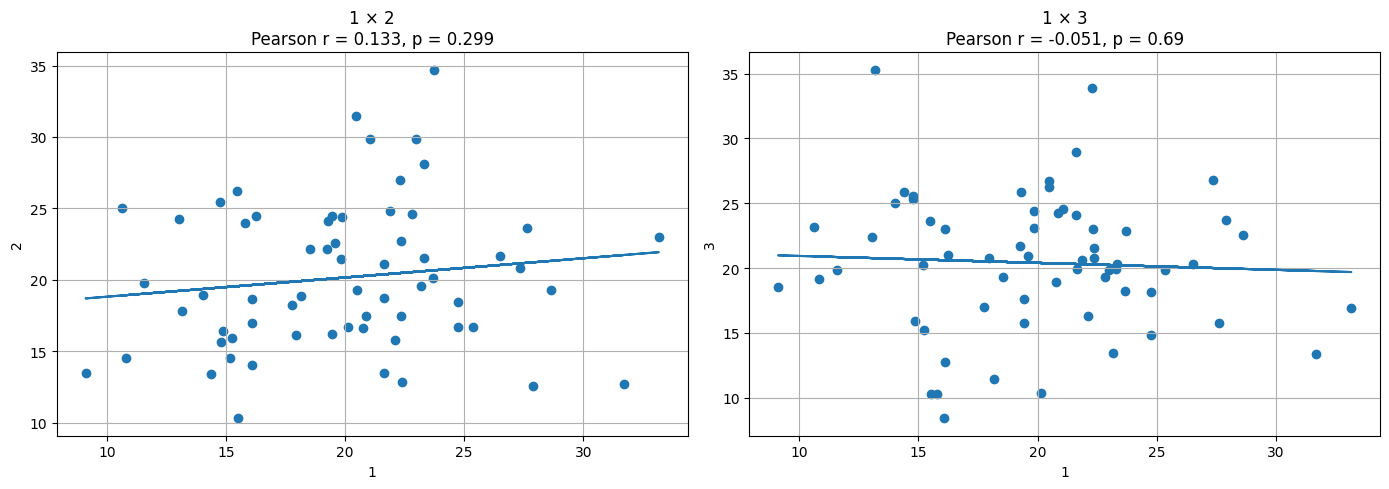

In [ ]:
from scipy.stats import pearsonr

# Função auxiliar para plotar correlação com linha de regressão
def plot_corr(ax, x, y, x_label, y_label):
    # Scatter
    ax.scatter(x, y)

    # Linha de regressão
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m * x + b)

    # Correlação de Pearson
    r, p = pearsonr(x, y)

    ax.set_title(f"{x_label} × {y_label}\nPearson r = {r:.3f}, p = {p:.3g}")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True)


# ===========================
# Subplots lado a lado
# ===========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — data1 x data2
plot_corr(
    ax=axes[0],
    #x = data2[data2["dia"] == "1"],
    x = data2.loc[data2["dia"] == 1, "consumo"],
    y = data2.loc[data2["dia"] == 2, "consumo"],
    x_label=1,
    y_label=2
)

# Gráfico 2 — data1 x data3
plot_corr(
    ax=axes[1],
    x = data2.loc[data2["dia"] == 1, "consumo"],
    y = data2.loc[data2["dia"] == 3, "consumo"],
    x_label=1,
    y_label=3
)

plt.tight_layout()
plt.show()


## Tratamento de dados

Remoção de outliers e dias inconsistentes para melhorar a qualidade da análise.

## Observação

Este tratamento foi usado no caso dos dados reais, para tratamento de outliers.

Antes do filtro: (2646, 3)
Depois do filtro: (2646, 3)
Após remover os dias fora de padrão: (2457, 3)


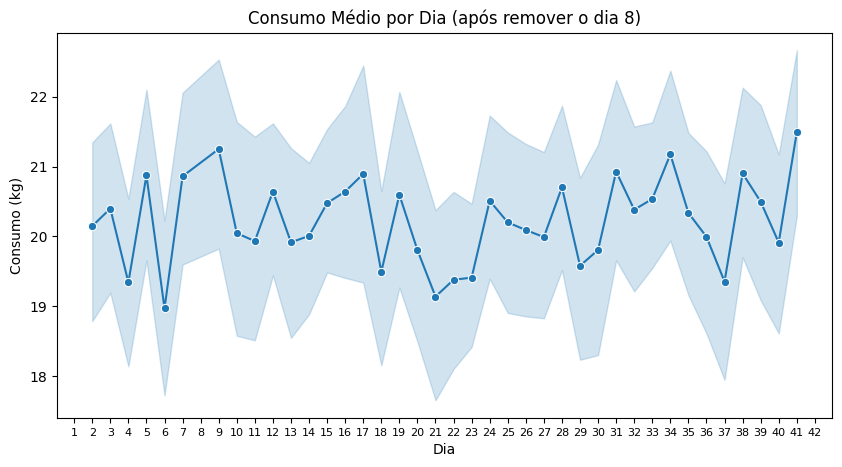

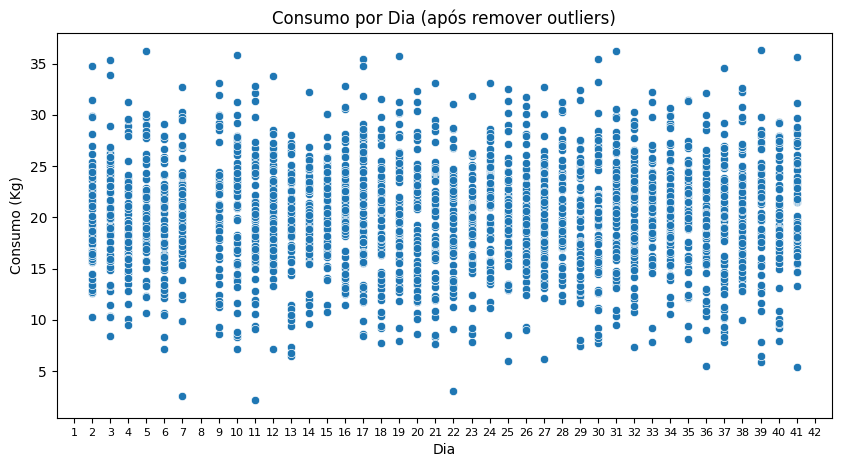

In [ ]:
# # TRATAMENTO DE OUTLIERS E DIA 8
# # consumo máximo a 60 kg

data2_filtrado = data2[data2["consumo"] <= 60].copy()

print("Antes do filtro:", data2.shape)
print("Depois do filtro:", data2_filtrado.shape)

# # Remover os dias 1, 8 e 42 (erro de balança no dia 8 e dias fora do padrão)
data2_filtrado = data2_filtrado[~data2_filtrado["dia"].isin([1, 8, 42])].copy()

print("Após remover os dias fora de padrão:", data2_filtrado.shape)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=data2_filtrado,
    x="dia",
    y="consumo",
    estimator="mean",
    marker="o"
)
plt.title("Consumo Médio por Dia (após remover o dia 8)")
plt.xlabel("Dia")
plt.xticks(ticks=range(1, 43, 1),fontsize=8)
plt.ylabel("Consumo (kg)")
plt.savefig("media_consumo_por_dia.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=data2_filtrado, x="dia", y="consumo")
plt.title("Consumo por Dia (após remover outliers)")
plt.xlabel("Dia")
plt.xticks(ticks=range(1, 43, 1), fontsize=8)
plt.ylabel("Consumo (Kg)")
plt.savefig("scatter_consumo_por_dia.png", bbox_inches="tight")
plt.show()


## Modelagem estatística

Aplicação de modelo linear misto para avaliar o comportamento do consumo ao longo do tempo, considerando variações individuais entre os animais.


--- Random intercept model (MixedLM) ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: consumo   
No. Observations: 2457    Method:             REML      
No. Groups:       63      Scale:              26.7279   
Min. group size:  39      Log-Likelihood:     -7533.6027
Max. group size:  39      Converged:          Yes       
Mean group size:  39.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     20.064    0.230 87.276 0.000 19.614 20.515
dia_num        0.007    0.009  0.790 0.430 -0.011  0.025
Group Var      0.164    0.030                           



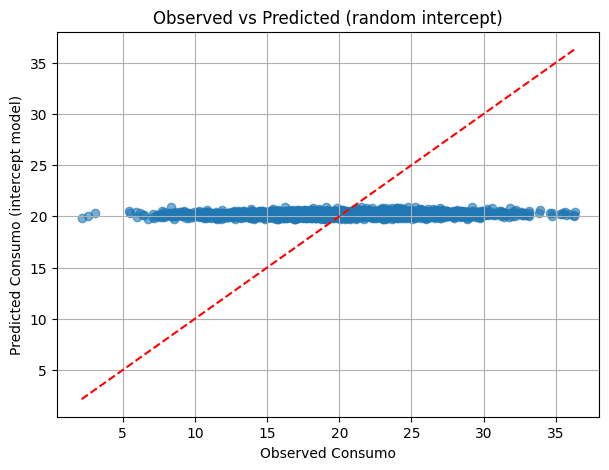


Coeficiente de Pearson (r): 0.1666
p-valor: 9.609e-17


In [ ]:
# a) Random intercept per Animal (and nested group approximation via group var)
data2_filtrado["dia_num"] = data2_filtrado["dia"]
formula = "consumo ~ dia_num"
md_intercept = mixedlm(formula, data2_filtrado, groups=data2_filtrado["TAG"])
m_intercept = md_intercept.fit(reml=True)
print("\n--- Random intercept model (MixedLM) ---")
print(m_intercept.summary())

# Predictions and diagnostic plot
data2_filtrado["pred_intercept"] = m_intercept.fittedvalues
plt.figure(figsize=(7,5))
plt.scatter(data2_filtrado["consumo"], data2_filtrado["pred_intercept"], alpha=0.6)
plt.plot([data2_filtrado["consumo"].min(), data2_filtrado["consumo"].max()], [data2_filtrado["consumo"].min(), data2_filtrado["consumo"].max()], 'r--')
plt.xlabel("Observed Consumo")
plt.ylabel("Predicted Consumo (intercept model)")
plt.title("Observed vs Predicted (random intercept)")
plt.grid(True)
plt.show()


# Calcular correlação entre observado e predito
r, p = pearsonr(data2_filtrado["consumo"], data2_filtrado["pred_intercept"])

print(f"\nCoeficiente de Pearson (r): {r:.4f}")
print(f"p-valor: {p:.4g}")

## Conclusão

- Os dados simulados não apresentaram relação significativa entre consumo e tempo
- O modelo linear misto resultou em baixa capacidade preditiva (r ≈ 0.16)
- Isso indica ausência de padrão temporal relevante na base simulada

## Observação

Por se tratar de dados simulados, não há estrutura real de dependência temporal, o que impacta diretamente o desempenho do modelo

## Comparação com dados reais

Na aplicação com dados reais do experimento, foram observados resultados mais satisfatórios, com presença de padrão temporal no consumo alimentar, permitindo melhor ajuste do modelo e maior capacidade explicativa.